Wczytanie odpowiednich bibliotek

In [10]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

import polars.selectors as cs
from pathlib import Path
from matplotlib import colormaps
from dataclasses import dataclass
from itertools import product

Zmiana katalogu roboczego

In [11]:
os.chdir('../..')

Wczytanie danych wynikowych

In [12]:
pl_data = pl.read_parquet('experiments/output/experiments_data.parquet')
print(f'Jest {pl_data.shape[0]:,} obserwacji i {pl_data.shape[1]:,} kolumn')

FileNotFoundError: No such file or directory (os error 2): experiments/output/experiments_data.parquet

This error occurred with the following context stack:
	[1] 'parquet scan'
	[2] 'sink'


In [4]:
print(pl_data.head)

<bound method DataFrame.head of shape: (2_908_800, 35)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ dataset    ┆ cpu_gpu ┆ balanced  ┆ model_con ┆ … ┆ model_spa ┆ ignored_v ┆ train_pre ┆ test_pred │
│ ---        ┆ ---     ┆ ---       ┆ fig_num   ┆   ┆ rsity     ┆ ariables_ ┆ d_time    ┆ _time     │
│ str        ┆ str     ┆ str       ┆ ---       ┆   ┆ ---       ┆ count     ┆ ---       ┆ ---       │
│            ┆         ┆           ┆ i64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ f64       │
│            ┆         ┆           ┆           ┆   ┆           ┆ i64       ┆           ┆           │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ japanese   ┆ cpu     ┆ balanced  ┆ 8         ┆ … ┆ 0.68      ┆ 1         ┆ 0.052602  ┆ 0.045218  │
│ japanese   ┆ cpu     ┆ balanced  ┆ 8         ┆ … ┆ 0.68      ┆ 1         ┆ 0.048895  ┆ 0.046869  │
│ japanese   ┆ cpu     ┆ balanced  ┆

In [13]:
print(pl_data.select('cpu_gpu','dataset','balanced').pivot('cpu_gpu', index='dataset', aggregate_function='len'))

shape: (5, 3)
┌─────────────────────┬────────┬────────┐
│ dataset             ┆ cpu    ┆ gpu    │
│ ---                 ┆ ---    ┆ ---    │
│ str                 ┆ u32    ┆ u32    │
╞═════════════════════╪════════╪════════╡
│ japanese            ┆ 290400 ┆ 295200 │
│ credit-approval     ┆ 290400 ┆ 290400 │
│ german-credit-data  ┆ 290400 ┆ 290400 │
│ lending-club        ┆ 290400 ┆ 290400 │
│ give-me-some-credit ┆ 290400 ┆ 290400 │
└─────────────────────┴────────┴────────┘


In [14]:
pl_grouped = pl_data.select('cpu_gpu','dataset','balanced','fold').group_by('dataset','cpu_gpu','fold').agg(pl.len())

In [15]:
pivoted_df = pl_data.select('cpu_gpu','dataset','balanced','fold').group_by('dataset','cpu_gpu','fold').agg(pl.len()).pivot(
    values="len",
    index="dataset",
    on=["cpu_gpu", "fold"]
)
pivoted_df = pivoted_df.select(sorted(pivoted_df.columns)).sort('dataset')

In [8]:
pivoted_df


dataset,"{""cpu"",10}","{""cpu"",1}","{""cpu"",2}","{""cpu"",3}","{""cpu"",4}","{""cpu"",5}","{""cpu"",6}","{""cpu"",7}","{""cpu"",8}","{""cpu"",9}","{""gpu"",10}","{""gpu"",1}","{""gpu"",2}","{""gpu"",3}","{""gpu"",4}","{""gpu"",5}","{""gpu"",6}","{""gpu"",7}","{""gpu"",8}","{""gpu"",9}"
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""credit-approval""",29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040
"""german-credit-data""",29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040
"""give-me-some-credit""",29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040
"""japanese""",29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29520,29520,29520,29520,29520,29520,29520,29520,29520,29520
"""lending-club""",29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040,29040


Skupienie się na jednym modelu wyłącznie i jednym datasetcie.
1. Sprawdzenie, jakie unikalne wartości mamy dla konkretnych kolumn

In [8]:
pl_data.columns

['dataset',
 'cpu_gpu',
 'balanced',
 'model_config_num',
 'fold',
 'epoch',
 'layers',
 'optimizer',
 'lr_mili',
 'auc',
 'binary_accuracy',
 'false_negatives',
 'false_positives',
 'loss',
 'precision',
 'recall',
 'true_negatives',
 'true_positives',
 'val_auc',
 'val_binary_accuracy',
 'val_false_negatives',
 'val_false_positives',
 'val_loss',
 'val_precision',
 'val_recall',
 'val_true_negatives',
 'val_true_positives',
 'train_time',
 'validation_time',
 'model_weights',
 'model_parameters_non_zero',
 'model_sparsity',
 'ignored_variables_count',
 'train_pred_time',
 'test_pred_time']

In [9]:
lst_columns = ['dataset',
 'cpu_gpu',
 'balanced',
 'model_config_num',
 'fold',
 'epoch',
 'layers',
 'optimizer']
dic_unique_values = dict()
for col in lst_columns:
    dic_unique_values[col] = pl_data.select(pl.col(col).unique()).to_series().to_list()

In [11]:
dic_unique_values

{'dataset': ['japanese',
  'credit-approval',
  'lending-club',
  'german-credit-data',
  'give-me-some-credit'],
 'cpu_gpu': ['cpu', 'gpu'],
 'balanced': ['balanced', 'unbalanced'],
 'model_config_num': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40],
 'fold': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'epoch': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30],
 'layers': [0, 1, 2, 3],
 'optimizer': ['adamax', 'adam', 'sgd', 'ftrl']}

Sprawdzenie, czy GPU lending club dla modelu nr 0 jest uwzględniony


In [12]:
@dataclass
class ModelParameters:
    """Class for selecting model paramters from polars dataframe"""
    dataset : str
    balanced : str
    model_config_num : int
    fold : int
    epoch : int
    layers : int
    optimizer : str

In [13]:
model_parameters_1 = ModelParameters('lending-club', 'balanced', 3, 1, 30, 3, 'adam')
lst_conditions = [pl.col(k) == v for k, v in model_parameters_1.__dict__.items()]
pl_data_filtered = pl_data.filter(lst_conditions)

In [14]:
lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', pl.col('model_config_num')== 3, pl.col('fold') == 1, 
                  pl.col('epoch') == 30, pl.col('layers') == 3, pl.col('optimizer') == 'adam']
pl_data.filter(lst_conditions).select('false_negatives', 'false_positives', 'true_negatives', 'true_positives', 'precision', 'recall', 'binary_accuracy')

false_negatives,false_positives,true_negatives,true_positives,precision,recall,binary_accuracy
f64,f64,f64,f64,f64,f64,f64
3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
3381.0,219.0,3723.0,561.0,0.719231,0.142314,0.543379


In [15]:
lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', pl.col('model_config_num')== 3, pl.col('fold') < 5, 
                  pl.col('epoch') == 30, pl.col('layers') == 3, pl.col('optimizer') == 'adam']
pl_data.filter(lst_conditions).select('cpu_gpu', 'fold','false_negatives', 'false_positives', 'true_negatives', 'true_positives', 'precision', 'recall', 'binary_accuracy').sort('fold','cpu_gpu')

cpu_gpu,fold,false_negatives,false_positives,true_negatives,true_positives,precision,recall,binary_accuracy
str,i64,f64,f64,f64,f64,f64,f64,f64
"""cpu""",1,3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
"""gpu""",1,3381.0,219.0,3723.0,561.0,0.719231,0.142314,0.543379
"""cpu""",2,3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
"""gpu""",2,3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
"""cpu""",3,3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
"""gpu""",3,0.0,3942.0,0.0,3942.0,0.5,1.0,0.5
"""cpu""",4,3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
"""gpu""",4,0.0,3942.0,0.0,3942.0,0.5,1.0,0.5


Fill between w zależności od epoki. Dla każdego będzie foldu. 


In [16]:
lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', pl.col('model_config_num')== 20, pl.col('layers') == 3, pl.col('optimizer') == 'adam']
pl_data1= pl_data.filter(lst_conditions).select('cpu_gpu', 'fold','epoch', 'false_negatives', 'false_positives', 'true_negatives', 'true_positives', 'precision', 'recall', 'binary_accuracy').sort('fold','cpu_gpu', 'epoch')

In [17]:
np_data = pl_data1.filter(pl.col('cpu_gpu')=='cpu', pl.col('fold') == 1).select('epoch','binary_accuracy').to_numpy()

In [18]:
np_data[:,0]

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30.])

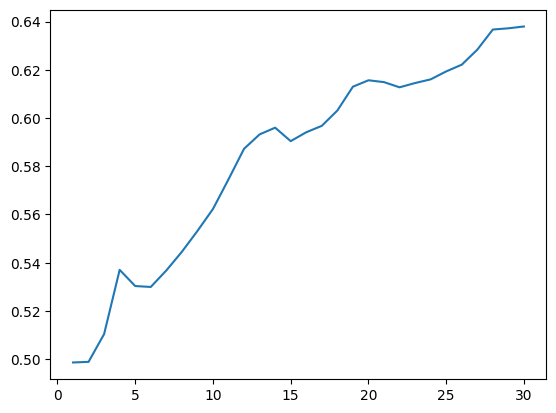

In [19]:
fig, ax = plt.subplots()
ax.plot(np_data[:,0], np_data[:,1])
plt.show()

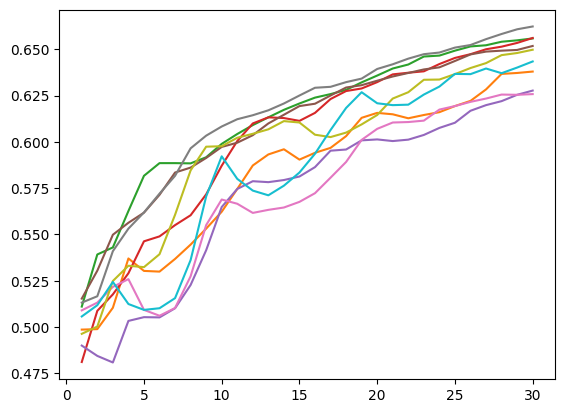

In [20]:
fig, ax = plt.subplots()
for i in range(10):
    np_data = pl_data1.filter(pl.col('cpu_gpu')=='cpu', pl.col('fold') == i).select('epoch','binary_accuracy').to_numpy()
    ax.plot(np_data[:,0], np_data[:,1])
plt.show()

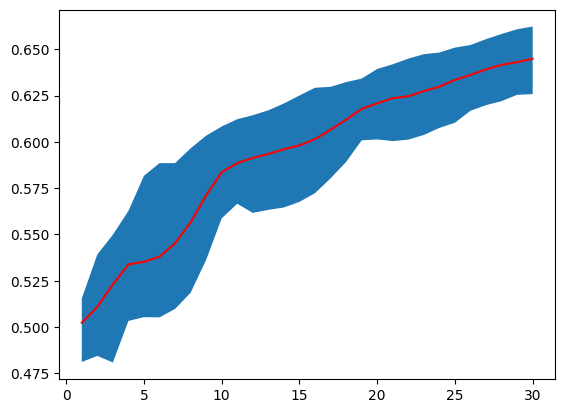

In [138]:
fig, ax = plt.subplots()
np_data = pl_data1.filter(pl.col('cpu_gpu')=='cpu').group_by(pl.col('epoch')).agg(
        pl.min('binary_accuracy').alias('min'), 
        pl.max('binary_accuracy').alias('max'),
        pl.mean('binary_accuracy').alias('mean'),
        ).sort('epoch').to_numpy()
ax.fill_between(np_data[:,0], y1=np_data[:,1], y2=np_data[:,2])
ax.plot(np_data[:,0], np_data[:,3], color='red')
plt.show()

Sprawdzić, jakie modele zostały zbadane i również je zobrazować


In [ ]:
def model_combinations():
    """Funkcja generująca kombinacje dla modeli, użyta przy uruchomeniu eksperymentów"""
    lst_units = [2**i for i in range(8, 0, -1)]
    lst_activations = ['relu', 'elu', 'sigmoid', 'softmax',  'tanh',]
    combinations = list(product(lst_units, lst_activations))
    return combinations

lst_models = [(0, '')] + model_combinations()
# pierwszy model, to model regresji logistycznej
print(lst_models)
print(len(lst_models))


lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', 
                  pl.col('model_config_num')== 1, pl.col('layers') < 4, pl.col('optimizer') == 'adam']
pl_model_weights = pl_data.filter(lst_conditions).select('model_weights').unique()

[(0, ''), (256, 'relu'), (256, 'elu'), (256, 'sigmoid'), (256, 'softmax'), (256, 'tanh'), (128, 'relu'), (128, 'elu'), (128, 'sigmoid'), (128, 'softmax'), (128, 'tanh'), (64, 'relu'), (64, 'elu'), (64, 'sigmoid'), (64, 'softmax'), (64, 'tanh'), (32, 'relu'), (32, 'elu'), (32, 'sigmoid'), (32, 'softmax'), (32, 'tanh'), (16, 'relu'), (16, 'elu'), (16, 'sigmoid'), (16, 'softmax'), (16, 'tanh'), (8, 'relu'), (8, 'elu'), (8, 'sigmoid'), (8, 'softmax'), (8, 'tanh'), (4, 'relu'), (4, 'elu'), (4, 'sigmoid'), (4, 'softmax'), (4, 'tanh'), (2, 'relu'), (2, 'elu'), (2, 'sigmoid'), (2, 'softmax'), (2, 'tanh')]
41


In [139]:
pl_data.columns

['dataset',
 'cpu_gpu',
 'balanced',
 'model_config_num',
 'fold',
 'epoch',
 'layers',
 'optimizer',
 'lr_mili',
 'auc',
 'binary_accuracy',
 'false_negatives',
 'false_positives',
 'loss',
 'precision',
 'recall',
 'true_negatives',
 'true_positives',
 'val_auc',
 'val_binary_accuracy',
 'val_false_negatives',
 'val_false_positives',
 'val_loss',
 'val_precision',
 'val_recall',
 'val_true_negatives',
 'val_true_positives',
 'train_time',
 'validation_time',
 'model_weights',
 'model_parameters_non_zero',
 'model_sparsity',
 'ignored_variables_count',
 'train_pred_time',
 'test_pred_time']

In [126]:
print(lst_models)

[(0, ''), (256, 'relu'), (256, 'elu'), (256, 'sigmoid'), (256, 'softmax'), (256, 'tanh'), (128, 'relu'), (128, 'elu'), (128, 'sigmoid'), (128, 'softmax'), (128, 'tanh'), (64, 'relu'), (64, 'elu'), (64, 'sigmoid'), (64, 'softmax'), (64, 'tanh'), (32, 'relu'), (32, 'elu'), (32, 'sigmoid'), (32, 'softmax'), (32, 'tanh'), (16, 'relu'), (16, 'elu'), (16, 'sigmoid'), (16, 'softmax'), (16, 'tanh'), (8, 'relu'), (8, 'elu'), (8, 'sigmoid'), (8, 'softmax'), (8, 'tanh'), (4, 'relu'), (4, 'elu'), (4, 'sigmoid'), (4, 'softmax'), (4, 'tanh'), (2, 'relu'), (2, 'elu'), (2, 'sigmoid'), (2, 'softmax'), (2, 'tanh')]


In [ ]:
print(955 * 256 + 256 * 2 + 1)
print(955 * 256 + 256 * 2 + 256 * 256 + 256 + 1)
print(955 * 256 + 256 * 2 + 256 * 256 + 256 + 1)

244993
310785


In [149]:
 lst_metrics = ['val_auc',
 'val_binary_accuracy',
 'val_loss',
 'val_precision',
 'val_recall',
 'train_time',
 'validation_time',
 'train_pred_time',
 'test_pred_time']

In [148]:
lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', 
                  pl.col('model_config_num')== 20, pl.col('layers') == 3, pl.col('optimizer') == 'adam',
                  pl.col('cpu_gpu') == 'cpu']
lst_columns = ['fold','epoch',] + lst_metrics
pl_data1= pl_data.filter(lst_conditions).select(lst_columns).sort('fold', 'epoch')

In [157]:
pl_data1.group_by("epoch").agg([
    pl.all().mean().name.suffix("_mean"),
    pl.all().max().name.suffix("_max"),
    pl.all().min().name.suffix("_min"),
]).sort('epoch')

epoch,fold_mean,val_auc_mean,val_binary_accuracy_mean,val_loss_mean,val_precision_mean,val_recall_mean,train_time_mean,validation_time_mean,train_pred_time_mean,test_pred_time_mean,fold_max,val_auc_max,val_binary_accuracy_max,val_loss_max,val_precision_max,val_recall_max,train_time_max,validation_time_max,train_pred_time_max,test_pred_time_max,fold_min,val_auc_min,val_binary_accuracy_min,val_loss_min,val_precision_min,val_recall_min,train_time_min,validation_time_min,train_pred_time_min,test_pred_time_min
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,5.5,0.517287,0.510845,0.695673,0.508366,0.53653,0.187917,0.077147,0.11807,0.053348,10,0.563445,0.530822,0.704564,0.535433,0.892694,0.196385,0.080343,0.124232,0.056338,1,0.456175,0.476027,0.689672,0.460967,0.09589,0.175933,0.072471,0.107939,0.048211
2,5.5,0.527022,0.515982,0.692529,0.517852,0.518037,0.104222,0.075313,0.110661,0.049071,10,0.574391,0.538813,0.700532,0.559028,0.746575,0.10817,0.079421,0.11807,0.053775,1,0.452933,0.471461,0.687174,0.469586,0.257991,0.099738,0.070133,0.103111,0.043858
3,5.5,0.535819,0.525114,0.691793,0.533483,0.512785,0.107347,0.075287,0.110627,0.049256,10,0.581423,0.560502,0.699398,0.563107,0.901827,0.114775,0.079051,0.118472,0.054251,1,0.453587,0.473744,0.685278,0.483734,0.157534,0.102912,0.067686,0.100026,0.043141
4,5.5,0.543988,0.524543,0.691735,0.534338,0.511644,0.103761,0.074425,0.110158,0.055797,10,0.585095,0.555936,0.699275,0.567123,0.922374,0.109937,0.078144,0.122962,0.060726,1,0.466327,0.487443,0.684469,0.493284,0.057078,0.099705,0.068699,0.09752,0.049634
5,5.5,0.552987,0.525571,0.691175,0.532417,0.527169,0.103137,0.072993,0.107231,0.052358,10,0.590091,0.559361,0.698767,0.571429,0.938356,0.110875,0.075939,0.113403,0.056211,1,0.481318,0.496575,0.683544,0.498182,0.02968,0.096525,0.070023,0.096374,0.047238
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26,5.5,0.620137,0.582991,0.672182,0.581811,0.592237,0.104763,0.076429,0.109441,0.051156,10,0.662671,0.614155,0.683624,0.615012,0.623288,0.110192,0.082345,0.121585,0.057774,1,0.583534,0.559361,0.658557,0.554865,0.527397,0.100162,0.07116,0.100312,0.045386
27,5.5,0.621504,0.588813,0.671656,0.585872,0.605708,0.10445,0.076142,0.108198,0.050219,10,0.662679,0.621005,0.684285,0.618304,0.652968,0.112406,0.083372,0.114798,0.056289,1,0.587235,0.562785,0.657801,0.561181,0.509132,0.100484,0.069397,0.09931,0.043282
28,5.5,0.622945,0.589612,0.67124,0.585638,0.611644,0.102778,0.073059,0.108356,0.057786,10,0.664415,0.609589,0.685101,0.606667,0.66895,0.109199,0.07844,0.114302,0.063403,1,0.588866,0.565068,0.657009,0.565032,0.502283,0.098866,0.068776,0.100559,0.049195


In [ ]:
df = pd.read_csv('/home/piotr/credit-data-exepriments/credit-data/data/folds/lending-club/fold01_train.csv', low_memory=False)


Funkcja do wczytywania danych na podstawie dataasetu i foldu. Usuwa kolumny, które nie należą do typu np.number

In [122]:
def read_train_test_fold_onprem(dataset:str, fold_num:int):
    """
    Reads data from bucket and returns train and test dataframes. 
    """
    dir_data = Path.home().joinpath(f'credit-data-exepriments/credit-data/data/folds/{dataset}')
    file_path_train = dir_data / f'fold{fold_num:02}_train.csv'
    file_path_test = dir_data / f'fold{fold_num:02}_test.csv'
    df_train = pd.read_csv(file_path_train, low_memory=False)
    df_test = pd.read_csv(file_path_test, low_memory=False)
    df_train = df_train.select_dtypes(include=np.number)
    df_test = df_test.select_dtypes(include=np.number)
    return df_train, df_test

def numpy_train_test_fold(df_train, df_test):
    return df_train.iloc[:,1:].to_numpy(), df_train.iloc[:,0].to_numpy(), \
           df_test.iloc[:,1:].to_numpy(), df_test.iloc[:,0].to_numpy()

In [124]:
dataset = 'lending-club'
df_train, df_test  = read_train_test_fold_onprem(dataset, 1)
print(f'Jest {len(df_train.columns):,} kolumn w zbiorze {dataset}, łącznie z kolumną target.')

Jest 956 kolumn w zbiorze lending-club, łącznie z kolumną target.


In [98]:
958 * 2    

1916

In [48]:
pl_data.filter(pl.col('balanced') == 'balanced').group_by('dataset', 'model_config_num', 'cpu_gpu', 'fold', 'model_weights').\
agg(pl.len(),pl.col('val_auc').mean(), pl.col('train_time').mean(), pl.col('train_pred_time').mean(), pl.col('test_pred_time').mean()).sort('dataset', 'model_config_num','cpu_gpu')

dataset,model_config_num,cpu_gpu,fold,model_weights,len,val_auc,train_time,train_pred_time,test_pred_time
str,i64,str,i64,i64,u32,f64,f64,f64,f64
"""credit-approval""",0,"""cpu""",6,38,120,0.702745,0.061961,0.050045,0.049369
"""credit-approval""",0,"""cpu""",7,38,120,0.420239,0.060787,0.049956,0.049626
"""credit-approval""",0,"""cpu""",5,38,120,0.561095,0.062677,0.050613,0.050185
"""credit-approval""",0,"""cpu""",8,38,120,0.37844,0.061683,0.049307,0.049439
"""credit-approval""",0,"""cpu""",9,38,120,0.507014,0.069309,0.055982,0.054938
…,…,…,…,…,…,…,…,…,…
"""lending-club""",40,"""gpu""",9,1921,120,0.519998,0.121359,0.14368,0.063324
"""lending-club""",40,"""gpu""",5,1921,120,0.529974,0.120794,0.143996,0.062552
"""lending-club""",40,"""gpu""",8,1915,120,0.499725,0.113399,0.137619,0.063139


In [108]:
pl_data.filter(pl.col('dataset') =='lending-club', pl.col('model_config_num') == 40).select('model_weights').unique().sort('model_weights')

model_weights
i64
1915
1921
1927


In [90]:
pl_data.filter(pl.col('dataset')=='lending-club', pl.col('layers')== 1).select('model_weights').unique().sort('model_weights')

model_weights
i64
1915
3829
7657
15313
30625
61249
122497
244993


In [ ]:
lst_conditions = [pl.col('dataset') == 'lending-club', pl.col('balanced') == 'balanced', pl.col('model_config_num')== 3, pl.col('fold') == 1, 
                  pl.col('epoch') == 30, pl.col('layers') == 3, pl.col('optimizer') == 'adam']
pl_data.filter(lst_conditions).select('false_negatives', 'false_positives', 'true_negatives', 'true_positives', 'precision', 'recall', 'binary_accuracy')

false_negatives,false_positives,true_negatives,true_positives,precision,recall,binary_accuracy
f64,f64,f64,f64,f64,f64,f64
3942.0,0.0,3942.0,0.0,0.0,0.0,0.5
3381.0,219.0,3723.0,561.0,0.719231,0.142314,0.543379


In [38]:
pl_data.filter(pl.col('balanced') == 'balanced', pl.col('dataset') == 'credit-approval')

dataset,cpu_gpu,balanced,model_config_num,fold,epoch,layers,optimizer,lr_mili,auc,binary_accuracy,false_negatives,false_positives,loss,precision,recall,true_negatives,true_positives,val_auc,val_binary_accuracy,val_false_negatives,val_false_positives,val_loss,val_precision,val_recall,val_true_negatives,val_true_positives,train_time,validation_time,model_weights,model_parameters_non_zero,model_sparsity,ignored_variables_count,train_pred_time,test_pred_time
str,str,str,i64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,f64
"""credit-approval""","""cpu""","""balanced""",0,5,1,0,"""adamax""","""default""",0.393976,0.480072,270.0,17.0,0.765891,0.26087,0.021739,259.0,6.0,0.436004,0.516129,30.0,0.0,0.766599,1.0,0.032258,31.0,1.0,0.109752,0.084556,38,38,0.0,0,0.048072,0.046815
"""credit-approval""","""cpu""","""balanced""",0,5,2,0,"""adamax""","""default""",0.394356,0.478261,270.0,18.0,0.764576,0.25,0.021739,258.0,6.0,0.439126,0.5,30.0,1.0,0.76519,0.5,0.032258,30.0,1.0,0.062664,0.087389,38,38,0.0,0,0.045195,0.050072
"""credit-approval""","""cpu""","""balanced""",0,5,3,0,"""adamax""","""default""",0.395932,0.481884,268.0,18.0,0.763275,0.307692,0.028986,258.0,8.0,0.441207,0.5,30.0,1.0,0.763794,0.5,0.032258,30.0,1.0,0.058311,0.070614,38,38,0.0,0,0.044386,0.052385
"""credit-approval""","""cpu""","""balanced""",0,5,4,0,"""adamax""","""default""",0.398242,0.480072,268.0,19.0,0.761987,0.296296,0.028986,257.0,8.0,0.449532,0.5,30.0,1.0,0.762413,0.5,0.032258,30.0,1.0,0.063897,0.079749,38,38,0.0,0,0.045066,0.048394
"""credit-approval""","""cpu""","""balanced""",0,5,5,0,"""adamax""","""default""",0.399063,0.480072,268.0,19.0,0.760713,0.296296,0.028986,257.0,8.0,0.443288,0.5,30.0,1.0,0.761045,0.5,0.032258,30.0,1.0,0.062296,0.075153,38,38,0.0,0,0.044972,0.05267
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""credit-approval""","""gpu""","""balanced""",26,10,26,2,"""adamax""","""default""",0.752968,0.67148,67.0,115.0,0.680981,0.646154,0.758123,162.0,210.0,0.858889,0.716667,3.0,14.0,0.67702,0.658537,0.9,16.0,27.0,0.095008,0.102246,385,385,0.0,0,0.051056,0.050303
"""credit-approval""","""gpu""","""balanced""",26,10,27,2,"""adamax""","""default""",0.757067,0.684116,63.0,112.0,0.680542,0.656442,0.772563,165.0,214.0,0.870556,0.716667,3.0,14.0,0.676421,0.658537,0.9,16.0,27.0,0.094693,0.101163,385,385,0.0,0,0.050895,0.049714
"""credit-approval""","""gpu""","""balanced""",26,10,28,2,"""adamax""","""default""",0.761446,0.687726,63.0,110.0,0.680108,0.660494,0.772563,167.0,214.0,0.876111,0.716667,3.0,14.0,0.67582,0.658537,0.9,16.0,27.0,0.093364,0.100692,385,385,0.0,0,0.050532,0.054324


Sprawdzenie, czy GPU lending club dla modelu nr 0 jest uwzględniony


In [21]:
pl_data1 = pl_data.filter( 
            pl.col('cpu_gpu')=='gpu', 
            pl.col('model_config_num') == 0,
            pl.col('fold') == 1).select('dataset').unique()
print(pl_data1)

shape: (2, 1)
┌─────────────────────┐
│ dataset             │
│ ---                 │
│ str                 │
╞═════════════════════╡
│ japanese            │
│ give-me-some-credit │
└─────────────────────┘


In [19]:
pl_data.filter(pl.col('cpu_gpu')=='gpu').group_by(['model_config_num','balanced','dataset']).len().sort(['model_config_num','balanced','dataset']).filter(pl.col("len") != 3600) 

model_config_num,balanced,dataset,len
i64,str,str,u32
0,"""balanced""","""give-me-some-credit""",1200
0,"""unbalanced""","""give-me-some-credit""",1200


Wybór danych dla jednego datastu i jednego foldu

In [ ]:
pl_data1 = pl_data.filter(pl.col('balanced')=='balanced', 
            pl.col('cpu_gpu')=='cpu', 
            pl.col('dataset') == 'give-me-some-credit',
            pl.col('fold') == 1)

In [ ]:
from src.experiments.analyze_dataset import show_scatter_plot_epochs

In [ ]:
show_scatter_plot_epochs(pl_data1, 'val_precision', 'val_recall')

In [ ]:
from itertools import combinations 
lst_metrics = ['val_auc',
'val_binary_accuracy',
'val_loss',
'val_precision',
'val_recall',
'train_time',
'validation_time',
'train_pred_time',
'test_pred_time']
tup_combinations  = tuple(combinations(lst_metrics, 2))

In [ ]:
for metric_x, metric_y in tup_combinations:
    # print(metric_x, metric_y)
    show_scatter_plot_epochs(pl_data1, metric_x, metric_y)

In [ ]:
pl_data1 = pl_data.filter(pl.col('balanced')=='balanced', 
            pl.col('cpu_gpu')=='cpu', 
            pl.col('dataset') == 'german-credit-data',
            pl.col('fold') == 1)

In [ ]:
for metric_x, metric_y in tup_combinations:
    # print(metric_x, metric_y)
    show_scatter_plot_epochs(pl_data1, metric_x, metric_y)